In [1]:
import matplotlib.pyplot as plt
import random
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
import numpy as np

#for WM811K
import cv2
import pandas as pd



In [ ]:
#Data for 811K
wm811K = pd.read_pickle('wm811K.pkl')

wm811K.info()

<class 'pandas.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   dieSize         811457 non-null  float64
 1   failureType     811457 non-null  object 
 2   lotName         811457 non-null  object 
 3   trainTestLabel  811457 non-null  object 
 4   waferIndex      811457 non-null  float64
 5   waferMap        811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 37.1+ MB


In [2]:
#Data for MixedWM38

data = np.load('MixedWM38.npz')
print(data.files)

['arr_0', 'arr_1']


WM811K attempt

In [ ]:
wm811K.head()

,dieSize,failureType,lotName,trainTestLabel,waferIndex,waferMap
0,1683.0,none,lot1,Training,1.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
1,1683.0,none,lot1,Training,2.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
2,1683.0,none,lot1,Training,3.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
3,1683.0,none,lot1,Training,4.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
4,1683.0,none,lot1,Training,5.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."


In [ ]:
#need to fix some of the dataset labels
wm811K.rename(columns={'trianTestlabel': 'trainTestLabel'}, inplace=True)
wm811K.waferIndex = wm811K.waferIndex.astype(int)
wm811K.tail()

,dieSize,failureType,lotName,trainTestLabel,waferIndex,waferMap
811452,600.0,Edge-Ring,lot47542,Test,23,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,..."
811453,600.0,Edge-Loc,lot47542,Test,24,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 1, 1,..."
811454,600.0,Edge-Ring,lot47542,Test,25,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,..."
811455,600.0,"[0, 0]",lot47543,"[0, 0]",1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,..."
811456,600.0,"[0, 0]",lot47543,"[0, 0]",2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,..."


In [ ]:
#Dont need index
wm811K.drop(['waferIndex'], axis = 1)

,dieSize,failureType,lotName,trainTestLabel,waferMap
0,1683.0,none,lot1,Training,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
1,1683.0,none,lot1,Training,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
2,1683.0,none,lot1,Training,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
3,1683.0,none,lot1,Training,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
4,1683.0,none,lot1,Training,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
...,...,...,...,...,...
811452,600.0,Edge-Ring,lot47542,Test,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,..."
811453,600.0,Edge-Loc,lot47542,Test,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 1, 1,..."
811454,600.0,Edge-Ring,lot47542,Test,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,..."
811455,600.0,"[0, 0]",lot47543,"[0, 0]","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,..."


In [ ]:
#Find wafer map dimensions
def find_dimension(x):
    dimension0 = np.size(x, 0)
    dimension1 = np.size(x, 1)
    return dimension0, dimension1
wm811K['waferMapDim'] = wm811K.waferMap.apply(find_dimension)
wm811K.sample(5)

,dieSize,failureType,lotName,trainTestLabel,waferIndex,waferMap,waferMapDim
739902,1507.0,none,lot44638,Test,6,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","(43, 44)"
355132,6052.0,"[0, 0]",lot21199,"[0, 0]",25,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","(86, 89)"
28482,741.0,"[0, 0]",lot2955,"[0, 0]",2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 1,...","(33, 29)"
47638,5085.0,"[0, 0]",lot4002,"[0, 0]",18,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","(87, 74)"
333006,1620.0,"[0, 0]",lot20087,"[0, 0]",25,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","(37, 55)"


In [ ]:
wm811K.memory_usage(deep=True)

Index                   132
dieSize             6491656
failureType        85867952
lotName            46088917
trainTestLabel     86004610
waferIndex          6491656
waferMap          110358152
waferMapDim        51933248
dtype: int64

In [ ]:
# Check the raw type and value of failureType for first few rows
for i in range(5):
    val = wm811K['failureType'].iloc[i]
    print(f"Row {i}: value={val}, type={type(val)}")

Row 0: value=none, type=<class 'str'>
Row 1: value=none, type=<class 'str'>
Row 2: value=none, type=<class 'str'>
Row 3: value=none, type=<class 'str'>
Row 4: value=none, type=<class 'str'>


In [ ]:
wm811K2 = wm811K.copy()

# Drop waferIndex column
# axis=1 means drop a column, axis=0 would drop a row
wm811K2 = wm811K2.drop(['waferIndex'], axis=1)

# Your version already has plain strings so just handle empty values
wm811K2.failureType = wm811K2.failureType.apply(
    lambda x: x if isinstance(x, str) and len(x) > 0 else float("NaN")
)

print(wm811K2['failureType'].value_counts())

failureType
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


In [ ]:
# Need to cut the unlabeled data for current model, may be good for unsupervised later
wm811K2 = wm811K2[wm811K2['failureType'].notnull()]
print(f"Remaining samples: {len(wm811K2)}")
print(wm811K2['failureType'].value_counts())

Remaining samples: 172950
failureType
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


In [ ]:
#Lets get some actual labels this time
label_811K = {'Center': 0, 'Donut': 1, 'Edge-Loc': 2, 'Edge-Ring': 3, 'Loc': 4, 'Scratch': 5,
               'Random': 6, 'Near-full': 7, 'none': 8}


In [ ]:
print(len(wm811K2))

172950


In [ ]:
#Need to process wafers for training
images_811k = []
labels_811k = []

for i in range(len(wm811K2)):
    img = cv2.resize(np.array(wm811K2['waferMap'].iloc[i], dtype = 'float32'), (52, 52)
    )
    #Split like other
    img = img / 2.0

    hot_encoding = np.zeros(9, dtype = 'float32')
    hot_encoding[label_811K[wm811K2['failureType'].iloc[i]]] = 1.0

    images_811k.append(img)
    labels_811k.append(hot_encoding)

In [ ]:
#Let's check some shapes
images_811k = np.stack(images_811k)
labels_811k = np.stack(labels_811k)

wm_images = np.expand_dims(images_811k, axis=1)

print(f"Images shape: {wm_images.shape}")  # Should be (172950, 1, 52, 52)
print(f"Labels shape: {labels_811k.shape}")  # Should be (172950, 9)

Images shape: (172950, 1, 52, 52)
Labels shape: (172950, 9)


In [ ]:
#Convert to tensors
wm_images_tensor = torch.tensor(wm_images)
labels_811k_tensor = torch.tensor(labels_811k).float()

print(wm_images_tensor.shape)
print(labels_811k_tensor.shape)

torch.Size([172950, 1, 52, 52])
torch.Size([172950, 9])


In [ ]:
#New test train split
wm_X_train, wm_X_test, wm_y_train, wm_y_test = train_test_split(
    wm_images_tensor, labels_811k_tensor, test_size=0.2, random_state=42
)

print(wm_X_train.shape)
print(wm_X_test.shape)

torch.Size([138360, 1, 52, 52])
torch.Size([34590, 1, 52, 52])


In [ ]:
#New dataloaders
train_811_dataset = TensorDataset(wm_X_train, wm_y_train)
test_811_dataset = TensorDataset(wm_X_test, wm_y_test)

train_811_loader = DataLoader(train_811_dataset, batch_size=64, shuffle=True)
test_811_loader = DataLoader(test_811_dataset, batch_size=64, shuffle=False)

print(len(train_811_loader))
print(len(test_811_loader))

2162
541


END OF WM811K Attempt

In [5]:
#Mixed Set

for key in data.files:
  print(key, data[key].shape)
  # 38,015 wafer maps, 52x52
  #arr_1 38,015 label vectors with length 8 for each defect present

arr_0 (38015, 52, 52)
arr_1 (38015, 8)


In [6]:
images = data['arr_0']
labels = data['arr_1']

#Adding 9th defect directly
no_defect = (labels.sum(axis = 1, keepdims = True) == 0).astype(np.float32)
labels = np.concatenate((labels, no_defect), axis = 1)

print("Image shape:", images.shape)
print("Label shape:", labels.shape)

Image shape: (38015, 52, 52)
Label shape: (38015, 9)


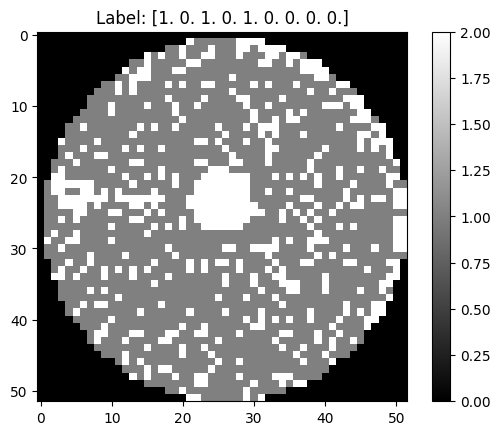

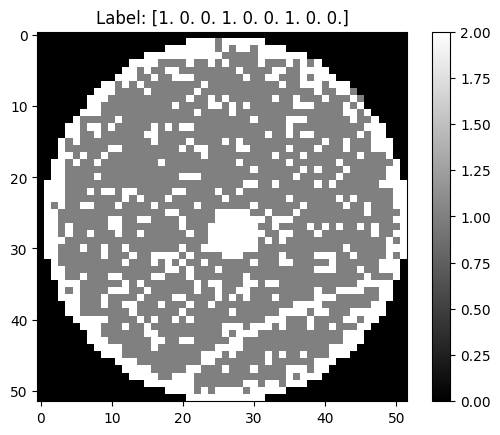

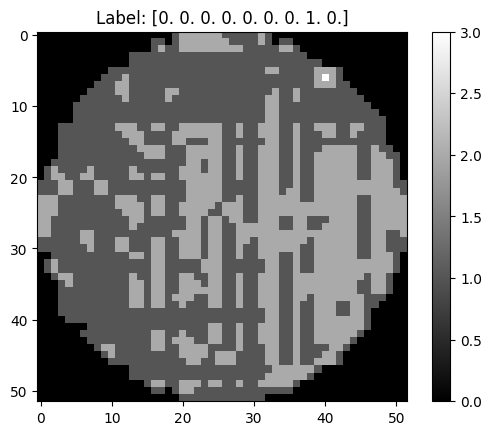

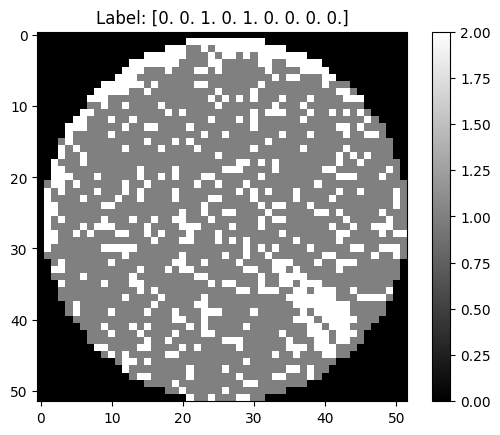

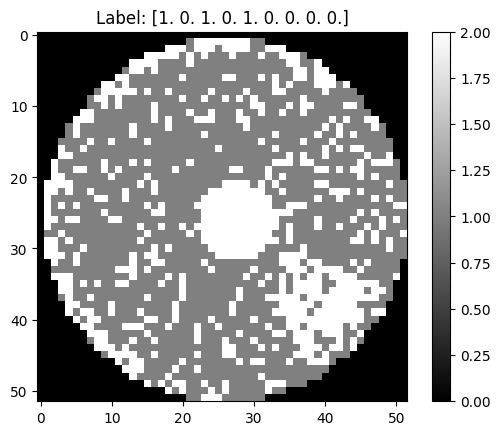

In [7]:
for i in random.sample(range(len(images)), 5):
  plt.imshow(images[i], cmap = 'gray')
  plt.title(f"Label: {labels[i]}")
  plt.colorbar()
  plt.show()

In [8]:
#Need to normalize the scale from 0-2 to 0-1
images = images.astype('float32')
images = images / 2.0

In [9]:
#Need to convert shape for pytorch
images = np.expand_dims(images, axis = 1)
print(images.shape)

(38015, 1, 52, 52)


In [10]:
#Count the defect dies per defect
def DefectCounter(image):
  return (image == 1.0).sum()
#1.0 == defect, 0.5 == good due to pre process

In [11]:
#make the values for both image shape and label shape into torch tensors
image_tensor = torch.tensor(images)
label_tensor = torch.tensor(labels).float()

print(image_tensor.shape)
print(label_tensor.shape)

torch.Size([38015, 1, 52, 52])
torch.Size([38015, 9])


In [12]:
#Test counting total dies per wafer class
defect_array = np.zeros(9)
#Fix Label tensor in order to get some count for 9th class

for i in range(len(images)):
  imageNum = images[i]
  labelNum = labels[i]

  current_Count = DefectCounter(imageNum)

  for j in range(len(labelNum)):
    if labelNum[j] == 1.0:
      defect_array[j] += current_Count
print(f'Number of defects per class: {defect_array}')


Number of defects per class: [ 8423293.  9025641.  8425165.  9003538. 12508552.   265663. 12750854.
   863236.   161571.]


In [13]:
#Split the data
X_train, X_test, y_train, y_test = train_test_split(image_tensor, label_tensor, test_size = 0.2, random_state = 42)
print(X_train.shape)
print(X_test.shape)

torch.Size([30412, 1, 52, 52])
torch.Size([7603, 1, 52, 52])


In [14]:
#Created dataloaders to process in batches

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 64)

In [15]:
#checked number of each defect type
print(label_tensor.sum(dim = 0))

tensor([13000., 12000., 13000., 12000., 18000.,   149., 19000.,   866.,  1000.])


In [16]:
#send to gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
#Starting the simple CNN
class SimpleCNN(nn.Module):
  #Autofilled by copiolt
  def __init__(self):
    super(SimpleCNN, self).__init__()

    #First layer: Input wafer 1, output 32, with kernel 3x3
    self.conv1 = nn.Conv2d(in_channels = 1, out_channels = 32, kernel_size = 3, padding =1)
    #adding batch normalization
    self.bn1 = nn.BatchNorm2d(32)

    #Second layer: take 32, output 64, same kernel
    self.conv2 = nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size = 3, padding = 1)
    self.bn2 = nn.BatchNorm2d(64)

    #3rd layer
    self.conv3 = nn.Conv2d(in_channels = 64, out_channels = 128, kernel_size = 3, padding = 1)
    self.bn3 = nn.BatchNorm2d(128)

    #4th layer
    self.conv4 = nn.Conv2d(in_channels = 128, out_channels =128, kernel_size = 3, padding = 1)
    self.bn4 = nn.BatchNorm2d(128)

    #5th layer
    self.conv5 = nn.Conv2d(in_channels = 128, out_channels = 256, kernel_size = 3, padding =1)
    self.bn5 = nn.BatchNorm2d(256)

    #reduce the size by half
    self.pool = nn.MaxPool2d(kernel_size = 2, stride = 2)
    #Try other Pooling methods like avgpool or globalavgpool
    #self.avgpool = nn.AvgPool2d(kernel_size = 2, stride = 2)
    #self.globalavgpool = nn.AdaptiveAvgPool2d((1, 1))


    #added dropout for overfitting
    self.dropout = nn.Dropout(0.25)
    #try different dropout rates or other regularization methods like weight decay or early stopping

    #connect layers; 13x13 because 52 -> 26 -> 13
    self.fc1 = nn.Linear(in_features = 256 * 1 * 1, out_features = 128)
    self.fc2Classify = nn.Linear(in_features = 128, out_features = 9) #Goes to 8 different defects
    #self.fc3Regression = nn.Linear(in_features = 128, out_features = 8) #Regression

  def forward(self, x):
    #52 - 26
    x = self.pool(F.relu(self.bn1((self.conv1(x)))))
    #26 - 13
    x = self.pool(F.relu(self.bn2((self.conv2(x)))))
    #
    x = self.pool(F.relu(self.bn3((self.conv3(x)))))
    #Recommended dropout to deal with overfitting
    x = self.dropout(x)
    #
    x = self.pool(F.relu(self.bn4((self.conv4(x)))))
    #
    x = self.pool(F.relu(self.bn5((self.conv5(x)))))
    x = self.dropout(x)

    x = x.view(x.size(0), -1)
    x = F.relu(self.fc1(x))
    #understand different use of activation functions

    #apply dropout
    x = self.dropout(x)
    ClassificationResult = self.fc2Classify(x)
    #RegressionResult = self.fc3Regression(x)

    return ClassificationResult

In [ ]:
#MIxed set
model = SimpleCNN().to(device)
#Loss function/ Added new loss for regression
criterion_class = nn.BCEWithLogitsLoss()
#criterion_regress = nn.MSELoss()
#Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001) #Changing around learning rate

In [ ]:
print(train_loader.batch_size)

64


In [ ]:
epoch_num = 50

for epoch in range(epoch_num):
    model.train()
    current_loss = 0.0
    #Computing training accuracy
    correct_train = 0
    total_train = 0

    for image, labels in train_loader:
        image = image.to(device)
        labels = labels.to(device)

        Classification_out = model(image)
        loss = criterion_class(Classification_out, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        current_loss += loss.item()

        #Training accuracy
        predicted = torch.sigmoid(Classification_out) > 0.5
        correct_train += (predicted == labels).all(dim=1).sum().item()
        total_train += labels.size(0)

    train_accuracy = correct_train / total_train
    print(f"Epoch [{epoch+1}/{epoch_num}], Loss: {current_loss/len(train_loader):.4f}, Train Accuracy: {train_accuracy:.4f}")

Epoch [1/50], Loss: 0.1217, Train Accuracy: 0.6972
Epoch [2/50], Loss: 0.0357, Train Accuracy: 0.9185
Epoch [3/50], Loss: 0.0258, Train Accuracy: 0.9433
Epoch [4/50], Loss: 0.0204, Train Accuracy: 0.9558
Epoch [5/50], Loss: 0.0178, Train Accuracy: 0.9626
Epoch [6/50], Loss: 0.0147, Train Accuracy: 0.9689
Epoch [7/50], Loss: 0.0132, Train Accuracy: 0.9718
Epoch [8/50], Loss: 0.0117, Train Accuracy: 0.9749
Epoch [9/50], Loss: 0.0112, Train Accuracy: 0.9762
Epoch [10/50], Loss: 0.0102, Train Accuracy: 0.9779
Epoch [11/50], Loss: 0.0085, Train Accuracy: 0.9819
Epoch [12/50], Loss: 0.0080, Train Accuracy: 0.9828
Epoch [13/50], Loss: 0.0073, Train Accuracy: 0.9845
Epoch [14/50], Loss: 0.0064, Train Accuracy: 0.9859
Epoch [15/50], Loss: 0.0059, Train Accuracy: 0.9876
Epoch [16/50], Loss: 0.0057, Train Accuracy: 0.9875
Epoch [17/50], Loss: 0.0058, Train Accuracy: 0.9875
Epoch [18/50], Loss: 0.0049, Train Accuracy: 0.9886
Epoch [19/50], Loss: 0.0044, Train Accuracy: 0.9894
Epoch [20/50], Loss: 

In [ ]:
#Multilabel accuracy
model.eval()
correct = 0
total = 0

with torch.no_grad():
  for image, labels in test_loader:
    image = image.to(device)
    labels = labels.to(device)
    #Including counts for regression
    #counts = counts.to(device)

    class_out = model(image)
    predicted = torch.sigmoid(class_out) > 0.5

    #Changed prediction labels to match only to 1's
    correct += (predicted == labels).all(dim = 1).sum().item()
    #.Numel = number of elements from torch
    total += labels.size(0)

    #Checking regression results
    #for i in range(20):
      #print(f"Predicted counts by regression: {reg_out[i]}")
      #print(f"Actual counts: {counts[i]}")

print("Accuracy:", correct / total)

Accuracy: 0.9807970537945547


In [ ]:
#accuracy was very high for the simple model, trying some other stuff
#Finding count of every label in the sample
all_labels = []
for _, labels in test_loader:
  all_labels.append(labels)

all_labels = torch.cat(all_labels)

print(f"Counting of each defect class: {all_labels.sum(dim = 0)}")

Counting of each defect class: tensor([2587., 2377., 2605., 2404., 3604.,   34., 3713.,  179.,  220.])


In [ ]:
#Using F1 like other papers
model.eval()
all_predictions = []
all_targets = []

with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(device)
    outputs = model(images)
    predictions = torch.sigmoid(outputs) > 0.5

    all_predictions.append(predictions.cpu())
    all_targets.append(labels)

all_predictions = torch.cat(all_predictions).numpy()
all_targets = torch.cat(all_targets).numpy()

print("Macro F1:", f1_score(all_targets, all_predictions, average = 'macro'))
print("Micro F1:", f1_score(all_targets, all_predictions, average = 'micro'))

Macro F1: 0.9908565435557323
Micro F1: 0.9949103658881412


In [ ]:
print(classification_report(all_targets, all_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2587
           1       1.00      1.00      1.00      2377
           2       1.00      0.98      0.99      2605
           3       0.99      1.00      0.99      2404
           4       1.00      0.99      0.99      3604
           5       0.97      0.94      0.96        34
           6       1.00      0.99      0.99      3713
           7       0.99      0.99      0.99       179
           8       1.00      1.00      1.00       220

   micro avg       1.00      0.99      0.99     17723
   macro avg       0.99      0.99      0.99     17723
weighted avg       1.00      0.99      0.99     17723
 samples avg       1.00      0.99      0.99     17723



c:\Users\raros\OneDrive\Desktop\VS code\WaferProject\defect_detect_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
#Check class distribution
print(y_train.sum(dim = 0 ))
print(y_test.sum( dim = 0))

tensor([10413.,  9623., 10395.,  9596., 14396.,   115., 15287.,   687.,   780.])
tensor([2587., 2377., 2605., 2404., 3604.,   34., 3713.,  179.,  220.])


811K implmentation

In [ ]:
wm_model = SimpleCNN().to(device)
# Loss function
wm_criterion = nn.BCEWithLogitsLoss()
# Optimizer
wm_optimizer = torch.optim.Adam(wm_model.parameters(), lr=0.001)

In [ ]:
epoch_num = 50

for epoch in range(epoch_num):
    wm_model.train()
    current_loss = 0.0

    for images, labels in train_811_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = wm_model(images)
        loss = wm_criterion(outputs, labels)

        wm_optimizer.zero_grad()
        loss.backward()
        wm_optimizer.step()

        current_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epoch_num}], Loss: {current_loss/len(train_811_loader):.4f}")

Epoch [1/50], Loss: 0.0345
Epoch [2/50], Loss: 0.0234
Epoch [3/50], Loss: 0.0205
Epoch [4/50], Loss: 0.0183
Epoch [5/50], Loss: 0.0168
Epoch [6/50], Loss: 0.0153
Epoch [7/50], Loss: 0.0140
Epoch [8/50], Loss: 0.0128
Epoch [9/50], Loss: 0.0117
Epoch [10/50], Loss: 0.0110
Epoch [11/50], Loss: 0.0100
Epoch [12/50], Loss: 0.0091
Epoch [13/50], Loss: 0.0085
Epoch [14/50], Loss: 0.0078
Epoch [15/50], Loss: 0.0073
Epoch [16/50], Loss: 0.0069
Epoch [17/50], Loss: 0.0065
Epoch [18/50], Loss: 0.0058
Epoch [19/50], Loss: 0.0056
Epoch [20/50], Loss: 0.0050
Epoch [21/50], Loss: 0.0050
Epoch [22/50], Loss: 0.0047
Epoch [23/50], Loss: 0.0046
Epoch [24/50], Loss: 0.0044
Epoch [25/50], Loss: 0.0042
Epoch [26/50], Loss: 0.0040
Epoch [27/50], Loss: 0.0037
Epoch [28/50], Loss: 0.0036
Epoch [29/50], Loss: 0.0035
Epoch [30/50], Loss: 0.0034
Epoch [31/50], Loss: 0.0035
Epoch [32/50], Loss: 0.0030
Epoch [33/50], Loss: 0.0030
Epoch [34/50], Loss: 0.0030
Epoch [35/50], Loss: 0.0028
Epoch [36/50], Loss: 0.0030
E

In [ ]:
wm_model.eval()
wm_all_predictions = []
wm_all_targets = []

with torch.no_grad():
    for images, labels in test_811_loader:
        images = images.to(device)
        outputs = wm_model(images)
        predictions = torch.sigmoid(outputs) > 0.5

        wm_all_predictions.append(predictions.cpu())
        wm_all_targets.append(labels)

wm_all_predictions = torch.cat(wm_all_predictions).numpy()
wm_all_targets = torch.cat(wm_all_targets).numpy()

print("WM-811K Results:")
print(f"Macro F1: {f1_score(wm_all_targets, wm_all_predictions, average='macro'):.4f}")
print(f"Micro F1: {f1_score(wm_all_targets, wm_all_predictions, average='micro'):.4f}")

WM-811K Results:
Macro F1: 0.8550
Micro F1: 0.9681


In [ ]:
#Accuracy for 811K
wm_model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_811_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = wm_model(images)
        
        predicted = torch.sigmoid(outputs) > 0.5

        
        correct += (predicted == labels).all(dim=1).sum().item()
        total += labels.size(0)

print(f"Accuracy: {correct / total:.4f}")

Accuracy: 0.9658


Starting GAN Implementation

In [ ]:
class_count = labels.sum(axis = 0)

for i, count in enumerate(class_count):
  print(f"Defect class {i + 1}: {int(count)} samples")

Defect class 1: 17 samples
Defect class 2: 16 samples
Defect class 3: 21 samples
Defect class 4: 14 samples
Defect class 5: 24 samples
Defect class 6: 0 samples
Defect class 7: 26 samples
Defect class 8: 3 samples
Defect class 9: 0 samples


In [ ]:
#I DID NOT WRITE THIS CODE
# latent_dim is the size of the random noise vector fed into the generator
latent_dim = 100

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        # Same architecture as the reference but outputs 52x52 instead of 28x28
        # nn.Sequential chains layers together in order
        self.model = nn.Sequential(
            # Takes random noise as input
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            # Output matches your wafer map size 52x52
            nn.Linear(512, 52 * 52),
            # tanh outputs values between -1 and 1 matching the reference
            nn.Tanh()
        )

    def forward(self, x):
        x = self.model(x)
        # Reshape flat output into image shape (batch, channel, height, width)
        return x.view(x.size(0), 1, 52, 52)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            # Flatten 52x52 image into a vector
            nn.Flatten(),
            nn.Linear(52 * 52, 512),
            # LeakyReLU allows small negative values, better for discriminator
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            # Single output — real or fake probability
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
# Normalize images to [-1, 1] to match tanh output of generator
# Your current images are in [0, 1] so we rescale
gan_images = (images - 0.5) / 0.5

# Convert to tensor
# images already has shape (38015, 1, 52, 52)
gan_image_tensor = torch.tensor(gan_images).float()

# DataLoader for GAN training — no labels needed for basic GAN
gan_dataset = TensorDataset(gan_image_tensor)
gan_loader = DataLoader(gan_dataset, batch_size=64, shuffle=True)

print(f"GAN dataset size: {len(gan_dataset)}")

GAN dataset size: 51


C:\Users\raros\AppData\Local\Temp\ipykernel_9504\75562484.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gan_image_tensor = torch.tensor(gan_images).float()


In [ ]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# BCELoss measures how well discriminator distinguishes real vs fake
gan_criterion = nn.BCELoss()

# Same learning rate and beta_1 as the reference implementation
gen_optimizer = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
dis_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [ ]:
epochs = 200

for epoch in range(epochs):
    epoch_d_loss = 0.0
    epoch_g_loss = 0.0
    num_batches = 0

    for (real_images,) in gan_loader:
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # Labels — 1 for real, 0 for fake
        # .fill_() fills tensor with a value
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # --- Train Discriminator ---
        dis_optimizer.zero_grad()

        # Real images
        real_predictions = discriminator(real_images)
        d_loss_real = gan_criterion(real_predictions, real_labels)

        # Fake images
        # torch.randn generates random noise from normal distribution
        noise = torch.randn(batch_size, latent_dim).to(device)
        fake_images = generator(noise)
        fake_predictions = discriminator(fake_images.detach())
        d_loss_fake = gan_criterion(fake_predictions, fake_labels)

        d_loss = 0.5 * (d_loss_real + d_loss_fake)
        d_loss.backward()
        dis_optimizer.step()

        # --- Train Generator ---
        gen_optimizer.zero_grad()

        noise = torch.randn(batch_size, latent_dim).to(device)
        fake_images = generator(noise)
        fake_predictions = discriminator(fake_images)
        # Generator wants discriminator to think fake images are real
        g_loss = gan_criterion(fake_predictions, real_labels)

        g_loss.backward()
        gen_optimizer.step()

        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()
        num_batches += 1

    print(f"Epoch [{epoch+1}/{epochs}] D Loss: {epoch_d_loss/num_batches:.4f} G Loss: {epoch_g_loss/num_batches:.4f}")

Epoch [1/200] D Loss: 0.6973 G Loss: 0.7268
Epoch [2/200] D Loss: 0.5614 G Loss: 0.7186
Epoch [3/200] D Loss: 0.4656 G Loss: 0.7103
Epoch [4/200] D Loss: 0.4075 G Loss: 0.6999
Epoch [5/200] D Loss: 0.3850 G Loss: 0.6871
Epoch [6/200] D Loss: 0.3817 G Loss: 0.6748
Epoch [7/200] D Loss: 0.3873 G Loss: 0.6634
Epoch [8/200] D Loss: 0.3954 G Loss: 0.6549
Epoch [9/200] D Loss: 0.4061 G Loss: 0.6503
Epoch [10/200] D Loss: 0.4104 G Loss: 0.6559
Epoch [11/200] D Loss: 0.4106 G Loss: 0.6784
Epoch [12/200] D Loss: 0.4067 G Loss: 0.7039
Epoch [13/200] D Loss: 0.4036 G Loss: 0.7385
Epoch [14/200] D Loss: 0.3978 G Loss: 0.7672
Epoch [15/200] D Loss: 0.3964 G Loss: 0.7886
Epoch [16/200] D Loss: 0.3963 G Loss: 0.8021
Epoch [17/200] D Loss: 0.4000 G Loss: 0.8030
Epoch [18/200] D Loss: 0.4155 G Loss: 0.8002
Epoch [19/200] D Loss: 0.4404 G Loss: 0.7921
Epoch [20/200] D Loss: 0.4543 G Loss: 0.7587
Epoch [21/200] D Loss: 0.4804 G Loss: 0.7528
Epoch [22/200] D Loss: 0.4940 G Loss: 0.7379
Epoch [23/200] D Lo

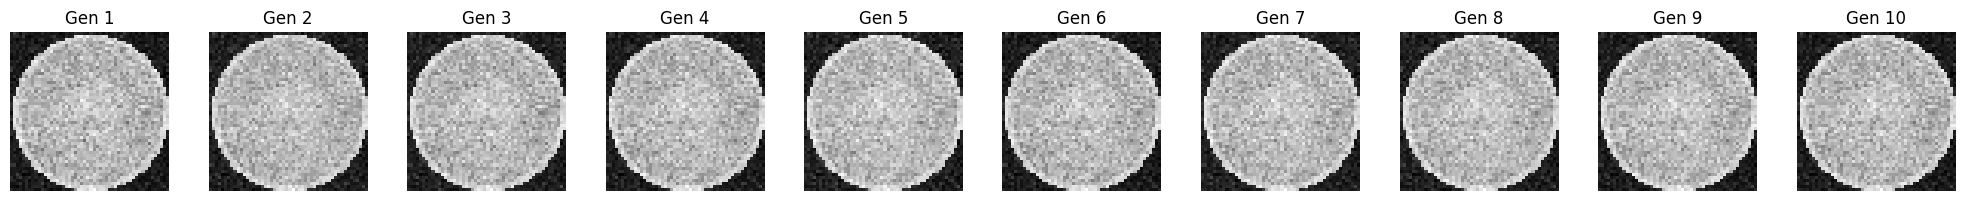

In [ ]:
generator.eval()

with torch.no_grad():
    # Generate 10 random wafer maps
    noise = torch.randn(10, latent_dim).to(device)
    generated = generator(noise).cpu()

    # Rescale from [-1, 1] back to [0, 1] for display
    generated = 0.5 * generated + 0.5

fig, axes = plt.subplots(1, 10, figsize=(20, 2))
for i in range(10):
    # .squeeze() removes the channel dimension for display
    axes[i].imshow(generated[i].squeeze(), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f"Gen {i+1}")
plt.tight_layout()
plt.show()

In [28]:
LATENT_SPACE_DIM = 100
img_shape = (1, 52, 52)
Tensor = torch.cuda.FloatTensor if torch.cuda.is_available() else torch.FloatTensor

def get_gaussian_latent_batch(device, batch_size=256):
    # Generates random noise from a gaussian distribution
    return torch.randn((batch_size, LATENT_SPACE_DIM), device=device)

class GeneratorNet(nn.Module):
    def __init__(self):
        super(GeneratorNet, self).__init__()
        # init_size is the starting spatial size before upsampling
        # 52 // 4 = 13
        self.init_size = img_shape[1] // 4

        self.fc = nn.Sequential(
            nn.Linear(LATENT_SPACE_DIM, 128 * self.init_size ** 2),
            nn.BatchNorm1d(128 * self.init_size ** 2),
            nn.ReLU(),
        )

        # Resize convolution blocks avoid checkerboarding
        # Upsample resizes then Conv2d learns features — better than ConvTranspose2d alone
        self.model = nn.Sequential(
            # Block 1: 13x13 -> 26x26
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            # Block 2: 26x26 -> 52x52
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            # Block 3: sharpen the output
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, img_shape[0], kernel_size=3, stride=1, padding=1),
            nn.Tanh(),
        )

    def forward(self, z):
        img = self.fc(z)
        img = img.view(img.shape[0], 128, self.init_size, self.init_size)
        img = self.model(img)
        return img


class DiscriminatorNet(nn.Module):
    def __init__(self):
        super(DiscriminatorNet, self).__init__()
        self.init_size = img_shape[1] // 4

        # LayerNorm is critical for WGAN-GP — do not swap for BatchNorm
        self.model = nn.Sequential(
            nn.Conv2d(img_shape[0], 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.LayerNorm([32, img_shape[1] // 2, img_shape[2] // 2]),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.LayerNorm([64, img_shape[1] // 4, img_shape[2] // 4]),
            nn.Flatten(),
            nn.Linear(64 * (self.init_size ** 2), 1),
        )
        # Note: no Sigmoid here — WGAN-GP uses raw scores not probabilities

    def forward(self, img):
        return self.model(img)

In [29]:
test_gen = GeneratorNet().to(device)
with torch.no_grad():
    test_gen.eval()  # Set to eval mode to bypass BatchNorm restriction
    test_noise = get_gaussian_latent_batch(device=device, batch_size=2)
    test_out = test_gen(test_noise)
    print(f"Generator output shape: {test_out.shape}")  # Should be (2, 1, 52, 52)

Generator output shape: torch.Size([2, 1, 52, 52])


In [30]:
class WGANGPModel:
    def __init__(self, data_loader, num_epochs, batch_size=256,
                 lambda_gp=10, n_critic=5, name="wgan"):
        self.data_loader = data_loader
        self.num_epochs = num_epochs
        self.batch_size = batch_size
        # lambda_gp controls how strongly gradient penalty is enforced
        self.lambda_gp = lambda_gp
        # n_critic means discriminator trains n times per generator update
        # this is key to WGAN-GP stability
        self.n_critic = n_critic
        self.name = name
        self.device = device

        self.d_net = DiscriminatorNet().train().to(device)
        self.g_net = GeneratorNet().train().to(device)

        # WGAN-GP uses different learning rates for generator and discriminator
        # discriminator lr is 10x lower than generator
        self.d_opt = Adam(self.d_net.parameters(), lr=0.00002, betas=(0.7, 0.99))
        self.g_opt = Adam(self.g_net.parameters(), lr=0.0002, betas=(0.7, 0.99))

        self.d_losses = []
        self.g_losses = []

    def _compute_gradient_penalty(self, real_images, fake_images):
        # Gradient penalty enforces the Lipschitz constraint
        # It interpolates between real and fake images and penalizes
        # gradients that deviate from norm 1
        alpha = Tensor(np.random.random((real_images.size(0), 1, 1, 1)))
        interpolates = (alpha * real_images + (1 - alpha) * fake_images).requires_grad_(True)
        d_interpolates = self.d_net(interpolates)
        fake = Tensor(real_images.size(0), 1).fill_(1.0).requires_grad_(False)

        gradients = autograd.grad(
            outputs=d_interpolates,
            inputs=interpolates,
            grad_outputs=fake,
            create_graph=True,
            retain_graph=True,
            only_inputs=True,
        )[0]

        gradients = gradients.view(gradients.size(0), -1)
        # Penalty is how far gradient norm deviates from 1
        gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
        return gradient_penalty

    def train(self):
        for epoch in range(self.num_epochs):
            epoch_d_loss = 0.0
            epoch_g_loss = 0.0
            num_batches = 0

            for batch_idx, (images, _) in enumerate(self.data_loader):
                real_images = images.type(Tensor)

                # --- Train Discriminator n_critic times ---
                for _ in range(self.n_critic):
                    self.d_opt.zero_grad()

                    z = get_gaussian_latent_batch(
                        batch_size=images.shape[0], device=self.device
                    )
                    fake_images = self.g_net(z)

                    real_validity = self.d_net(real_images)
                    fake_validity = self.d_net(fake_images.detach())
                    gradient_penalty = self._compute_gradient_penalty(
                        real_images, fake_images.detach()
                    )

                    # WGAN-GP loss — maximizes difference between real and fake scores
                    d_loss = (
                        -torch.mean(real_validity)
                        + torch.mean(fake_validity)
                        + self.lambda_gp * gradient_penalty
                    )
                    d_loss.backward()
                    self.d_opt.step()

                # --- Train Generator ---
                self.g_opt.zero_grad()

                z = get_gaussian_latent_batch(
                    batch_size=images.shape[0], device=self.device
                )
                fake_images = self.g_net(z)
                fake_validity = self.d_net(fake_images)
                # Generator wants to maximize discriminator score on fake images
                g_loss = -torch.mean(fake_validity)

                g_loss.backward()
                self.g_opt.step()

                epoch_d_loss += d_loss.item()
                epoch_g_loss += g_loss.item()
                num_batches += 1

            self.d_losses.append(epoch_d_loss / num_batches)
            self.g_losses.append(epoch_g_loss / num_batches)
            print(f"Epoch [{epoch+1}/{self.num_epochs}] "
                  f"D Loss: {epoch_d_loss/num_batches:.4f} "
                  f"G Loss: {epoch_g_loss/num_batches:.4f}")

    def generate(self, num_images):
        # Generate num_images samples from trained generator
        self.g_net.eval()
        with torch.no_grad():
            z = get_gaussian_latent_batch(batch_size=num_images, device=self.device)
            generated = self.g_net(z).cpu()
            # Rescale from [-1,1] back to [0,1]
            generated = 0.5 * generated + 0.5
        return generated

In [31]:
# We train a separate GAN for each minority class
# This is the approach used in the reference notebook
target_classes = [5, 7, 8]  # indices for classes 6, 8, 9 (0-indexed)

# Rescale images to [-1,1]
gan_images = (images - 0.5) / 0.5
gan_image_tensor = torch.tensor(gan_images).float()
gan_label_indices = torch.tensor(labels.argmax(axis=1)).long()

class_loaders = {}
for class_idx in target_classes:
    # Boolean mask selects only wafers belonging to this class
    mask = gan_label_indices == class_idx
    class_images = gan_image_tensor[mask]
    class_labels = gan_label_indices[mask]

    dataset = TensorDataset(class_images, class_labels)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)
    class_loaders[class_idx] = loader
    print(f"Class {class_idx+1}: {len(dataset)} samples")

Class 6: 149 samples
Class 8: 866 samples
Class 9: 1000 samples


In [32]:
from torch.optim import Adam
import torch.autograd as autograd

In [33]:
# Dictionary to store trained GAN for each class
trained_gans = {}

for class_idx in target_classes:
    print(f"\n--- Training GAN for Class {class_idx+1} ---")
    gan_model = WGANGPModel(
        data_loader=class_loaders[class_idx],
        num_epochs=1000,
        batch_size=64,
        lambda_gp=10,
        n_critic=5,
        name=f"class_{class_idx+1}"
    )
    gan_model.train()
    trained_gans[class_idx] = gan_model
    print(f"Class {class_idx+1} GAN training complete")


--- Training GAN for Class 6 ---
Epoch [1/1000] D Loss: 1.3858 G Loss: 0.6656
Epoch [2/1000] D Loss: -1.2759 G Loss: 0.8989
Epoch [3/1000] D Loss: -3.0784 G Loss: 1.0965
Epoch [4/1000] D Loss: -4.4661 G Loss: 1.2122
Epoch [5/1000] D Loss: -6.0406 G Loss: 1.4334
Epoch [6/1000] D Loss: -7.2956 G Loss: 1.5583
Epoch [7/1000] D Loss: -8.3617 G Loss: 1.6974
Epoch [8/1000] D Loss: -9.4722 G Loss: 2.0495
Epoch [9/1000] D Loss: -10.8375 G Loss: 2.3203
Epoch [10/1000] D Loss: -11.8267 G Loss: 2.5140
Epoch [11/1000] D Loss: -12.8204 G Loss: 2.2248
Epoch [12/1000] D Loss: -13.8406 G Loss: 1.5836
Epoch [13/1000] D Loss: -14.3866 G Loss: 0.9304
Epoch [14/1000] D Loss: -14.9498 G Loss: 0.5200
Epoch [15/1000] D Loss: -14.7533 G Loss: -0.0808
Epoch [16/1000] D Loss: -14.5862 G Loss: -0.1534
Epoch [17/1000] D Loss: -14.2567 G Loss: -1.0956
Epoch [18/1000] D Loss: -13.5430 G Loss: -1.2791
Epoch [19/1000] D Loss: -13.3490 G Loss: -1.7455
Epoch [20/1000] D Loss: -12.1517 G Loss: -2.1557
Epoch [21/1000] D 

KeyboardInterrupt: 

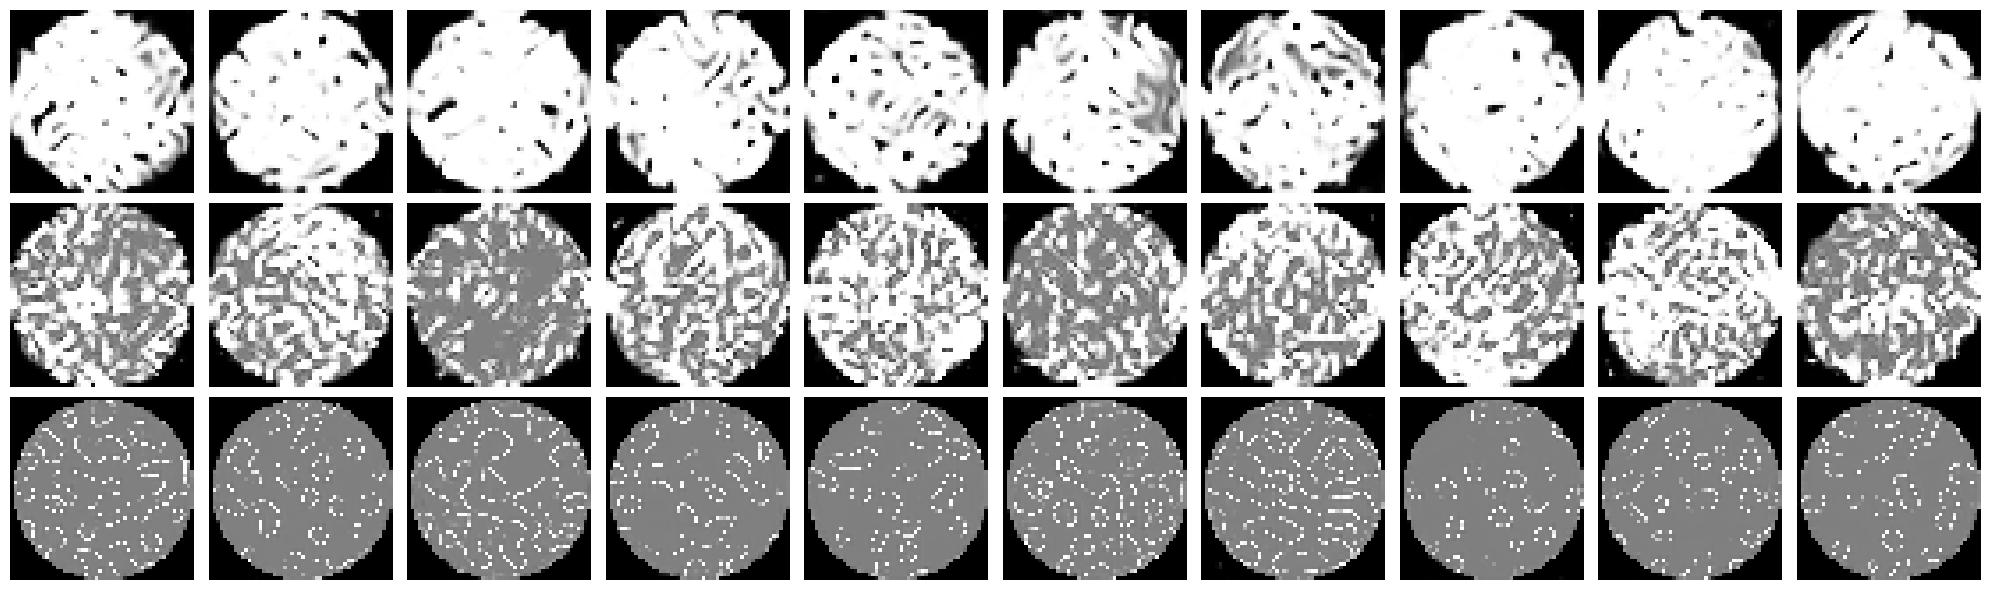

In [27]:
class_names = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']

fig, axes = plt.subplots(len(target_classes), 10, figsize=(20, 6))

for row, class_idx in enumerate(target_classes):
    generated = trained_gans[class_idx].generate(10)
    for col in range(10):
        axes[row, col].imshow(generated[col].squeeze(), cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(class_names[class_idx], fontsize=12)

plt.tight_layout()
plt.show()